# Packages & Global Info

In [12]:
# Packages 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [13]:
# Aggregation levels
levels = {'1 min': 1/60, '10 min': 1/6, '30 min': 0.5, '1 h': 1,
              '2 h': 2, '3 h': 3, '4 h': 4, '6 h': 6, '8 h': 8, '12 h': 12, '24 h': 24}

agg_levels = np.array([h for _, h in levels.items()])

# JACCARD

In [14]:
# Jaccard results
JACCARD_df = pd.read_csv("/home/ma/t/tr725/MSc-Project/04_code/jaccard/jaccard.csv", index_col=0)

JACCARD = {}
for col in JACCARD_df.columns:
    JACCARD[col] = {
        tuple(int(x) for x in idx.split("-")): val
        for idx, val in JACCARD_df[col].items()
    }

# ARI

In [15]:
# ARI results
ARI_df = pd.read_csv("/home/ma/t/tr725/MSc-Project/04_code/ARI/ARI.csv", index_col=0)

ARI = {}
for col in ARI_df.columns:
    ARI[col] = {
        tuple(int(x) for x in idx.split("-")): val
        for idx, val in ARI_df[col].items()
    }

# VI

In [16]:
# VI results 
VI_df = pd.read_csv("/home/ma/t/tr725/MSc-Project/04_code/VI/VI.csv", index_col=0)

VI = {}
for col in VI_df.columns:
    VI[col] = {
        tuple(int(x) for x in idx.split("-")): val
        for idx, val in VI_df[col].items()
    }
    
inv_VI = {name: {pair: 1 - v for pair, v in d.items()} for name, d in VI.items()}


# PSI

In [17]:
# PSI results
PSI_df = pd.read_csv("/home/ma/t/tr725/MSc-Project/04_code/PSI/PSI.csv", index_col=0)

PSI = {}
for col in PSI_df.columns:
    PSI[col] = {
        tuple(int(x) for x in idx.split("-")): val
        for idx, val in PSI_df[col].items()
    }

# Combined

In [18]:
# Combined results
COMBINED_df = pd.read_csv("/home/ma/t/tr725/MSc-Project/04_code/combined/combined.csv", index_col=0)

COMBINED = {}
for col in COMBINED_df.columns:
    COMBINED[col] = {
        tuple(int(x) for x in idx.split("-")): val
        for idx, val in COMBINED_df[col].items()
    }

# Correlations

## 3 Stability measures correlation

In [19]:
# Pairwise correlations between measures at each aggregation level
corr_ari_vi  = []
corr_ari_psi = []
corr_vi_psi  = []

for agg_level in levels:
    pairs = list(ARI[agg_level].keys())
    ari = np.array([ARI[agg_level][p] for p in pairs]) 
    vi  = np.array([inv_VI[agg_level][p] for p in pairs])
    psi = np.array([PSI[agg_level][p] for p in pairs]) 

    corr_ari_vi.append(np.corrcoef(ari, vi)[0, 1])
    corr_ari_psi.append(np.corrcoef(ari, psi)[0, 1])
    corr_vi_psi.append(np.corrcoef(vi, psi)[0, 1])

corr_ari_vi  = np.array(corr_ari_vi)
corr_ari_psi = np.array(corr_ari_psi)
corr_vi_psi  = np.array(corr_vi_psi)

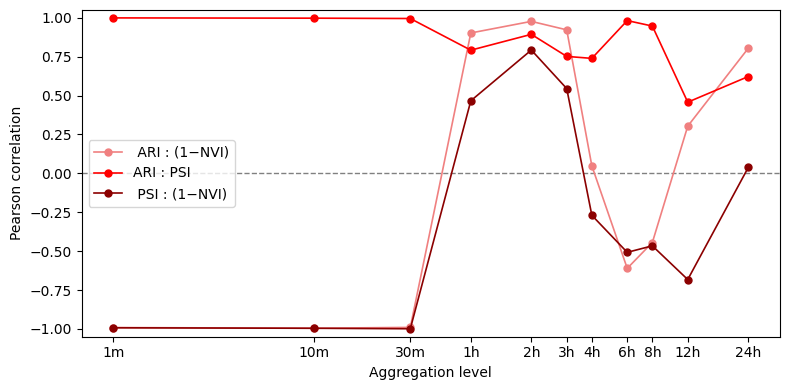

In [20]:
# Plot of correlations
fig, ax = plt.subplots(figsize=(8, 4))

ax.axhline(0, color='grey', lw=1, ls='--', zorder=1)

ax.plot(agg_levels, corr_ari_vi,  marker='o', ms=5, lw=1.2, label=' ARI : (1−NVI)', color = 'lightcoral')
ax.plot(agg_levels, corr_ari_psi, marker='o', ms=5, lw=1.2, label='ARI : PSI', color = 'red')
ax.plot(agg_levels, corr_vi_psi,  marker='o', ms=5, lw=1.2, label=' PSI : (1−NVI)', color = 'darkred')

ax.set_xscale('log')
ax.set_xticks(agg_levels)
ax.set_xticklabels(['1m','10m','30m','1h','2h','3h','4h','6h','8h','12h','24h'])
ax.minorticks_off()
ax.set_xlabel('Aggregation level')
ax.set_ylabel('Pearson correlation')
ax.set_ylim(-1.05, 1.05)
ax.legend(loc='center left')
plt.tight_layout()

## JACCARD & Combined correlation

In [21]:
# Pairwise correlations between Jaccard and Combined stability index at each aggregation level   
corr = []

for agg_level in levels:
    pairs = list(COMBINED[agg_level].keys())
    jaccard = np.array([JACCARD[agg_level][p] for p in pairs]) 
    combined = np.array([COMBINED[agg_level][p] for p in pairs]) 

    corr.append(np.corrcoef(jaccard, combined)[0, 1])

corr  = np.array(corr)

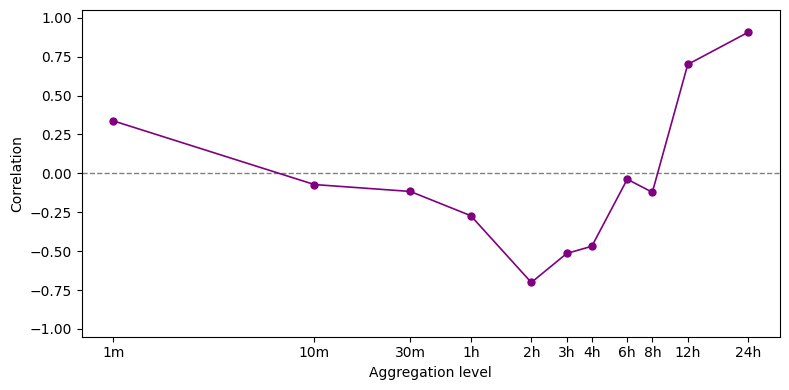

In [22]:
# Plot of correlations
fig, ax = plt.subplots(figsize=(8, 4))

ax.axhline(0, color='grey', lw=1, ls='--', zorder=1)

ax.plot(agg_levels, corr,  marker='o', ms=5, lw=1.2, color = 'purple')

ax.set_xscale('log')
ax.set_xticks(agg_levels)
ax.set_xticklabels(['1m','10m','30m','1h','2h','3h','4h','6h','8h','12h','24h'])
ax.minorticks_off()
ax.set_xlabel('Aggregation level')
ax.set_ylabel('Correlation')
ax.set_ylim(-1.05, 1.05)
plt.tight_layout()